# Heatwave Analysis: Products & Insights
**Final Project:** Heatwave Analysis in Rio de Janeiro State

**Course:** FA25-BL-EAS-G690-29302

**Professor:** Travis Allen O'Brien

**Step:** Heatwave Products and Analysis

**Author:** Rafaela Quintella Veiga

**Date:** December 2025

---

## Overview
This notebook compiles the final products generated from the extraction and heatwave-detection workflows. The objective is to create publication-quality visual analyses that summarize how heatwaves behave across Rio de Janeiro State and its municipalities over the last decades (1940–2024).

**Key Analyses**

. How do heatwaves vary spatially across the state of Rio de Janeiro?

. How has the frequency of heatwaves changed between 1940-1960 and 2004–2024 across the state’s municipalities?

. What are the differences in the temporal trends of heatwaves among the city of Rio de Janeiro (the capital), Petrópolis (a high-altitude municipality), and the state as a whole?



## 1. Data Loading & Filtering

In this step, we load the master event table and select only the regions that will be compared in the visual analyses.

Purpose

- Import the full event catalog (MASTER_events_all_regions.csv).

- Filter the dataset to retain only the regions of interest (e.g., Rio de Janeiro, Petrópolis, RJ_State).

- Prepare a clean subset that will serve as the basis for all figures in this notebook.

Notes

- Only rows corresponding to selected regions are kept.

- No transformations are applied yet; this step strictly isolates the analysis domain.

In [1]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import itertools
from matplotlib.ticker import MaxNLocator
from scipy import stats
import string

# --- Configuration ---
# Path to the MASTER EVENTS file (generated in the previous step)
PATH_EVENTS = r"C:\Users\rafaq\EASG690\Final_Project\scripts\heatwave_analysis\outputs\MASTER_events_all_regions.csv"

# Regions of interest for the plot
SELECTED_REGIONS = ['RJ_State', 'Petrópolis',  'Rio de Janeiro']

# Correct category order 
DURATION_ORDER = ['3-4 days', '5-7 days', '>7 days']
PERCENTILE_ORDER = [80, 90, 95]

# Visual Configuration 
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

In [2]:
# ==============================================================================
# 1. Loading and Filtering
# ==============================================================================
if os.path.exists(PATH_EVENTS):
    df_raw = pd.read_csv(PATH_EVENTS)
    
    # Filter only the 3 regions we want to compare
    df_main = df_raw[df_raw['region'].isin(SELECTED_REGIONS)].copy()
    
    print(f"✅ Data loaded. Total filtered events: {len(df_main)}")
else:
    raise FileNotFoundError(f"File not found: {PATH_EVENTS}")

✅ Data loaded. Total filtered events: 2761


## 2. Data Preparation (Handling Zero-Event Years)

Heatwave events do not occur every year in every region. Because the raw event table only lists years with events, several years are missing from the dataset. To generate accurate time-series plots, we must explicitly account for years with zero events.

**Goal**

Create a complete year-by-year dataset with:

- Every year in the analysis range

- Every selected region

- Every percentile threshold

- Every duration category
    → Filling missing combinations with 0 events

**Approach**

1. Generate a “skeleton” structure:
   All possible combinations of Year × Region × Percentile × Duration.

2. Merge with actual event counts:
   Count events in the raw table and join to the skeleton.

3. Fill missing values with zero:
   Ensures that all years are represented, even when no heatwaves occurred.

**Outcome**

A fully populated dataset (df_plot) ready for consistent interannual comparison.

In [3]:
# ==============================================================================
# 2. Data Preparation (The Trick: Filling Zeros)
# ==============================================================================

# A. Create a "Skeleton" with all possible combinations of Year, Region, Percentile, and Duration
years = np.arange(df_main['year'].min(), df_main['year'].max() + 1)

# Generate all combinations
combinations = list(itertools.product(
    years, 
    SELECTED_REGIONS, 
    PERCENTILE_ORDER, 
    DURATION_ORDER
))

# Create base DataFrame (initially empty/zero structure)
df_skeleton = pd.DataFrame(combinations, columns=['year', 'region', 'percentile', 'duration_category'])

# B. Count actual events in the data
events_count = df_main.groupby(['year', 'region', 'percentile', 'duration_category']).size().reset_index(name='event_count')

# C. Merge the Skeleton with Actual Counts
# Left merge ensures we keep all years from the skeleton, even if they match nothing in events_count
df_plot = pd.merge(df_skeleton, events_count, on=['year', 'region', 'percentile', 'duration_category'], how='left')

# D. Fill NaNs with 0 (Representing years without heatwaves)
df_plot['event_count'] = df_plot['event_count'].fillna(0)

print("✅ Data prepared for plotting (zeros filled).")
display(df_plot.head())

✅ Data prepared for plotting (zeros filled).


,year,region,percentile,duration_category,event_count
0,1940,RJ_State,80,3-4 days,2.0
1,1940,RJ_State,80,5-7 days,1.0
2,1940,RJ_State,80,>7 days,0.0
3,1940,RJ_State,90,3-4 days,1.0
4,1940,RJ_State,90,5-7 days,0.0


## 3. Visualization: Comparative Time Series Panel
This section generates a multi-panel time-series figure that compares how heatwave frequency varies across regions, percentiles, and duration categories.
The layout is designed to highlight how stricter heatwave definitions (higher percentiles and longer duration thresholds) influence the detection of events across regions with distinct physiographic characteristics, such as coastal lowlands, mountainous areas, and the statewide average.

**Figure Design:**
* **X-Axis:** Time (Year).
* **Y-Axis:** Frequency (Number of Events).
* **Rows:** Intensity Thresholds (80th, 90th, 95th Percentiles).
* **Columns:** Duration Categories (3-4 days, 5-7 days, >7 days).
* **Color:** Regions (Rio de Janeiro vs. Petrópolis vs. State Average).

This layout allows for a direct comparison of how stricter definitions (higher percentiles/longer durations) affect the detected frequency across different climates.

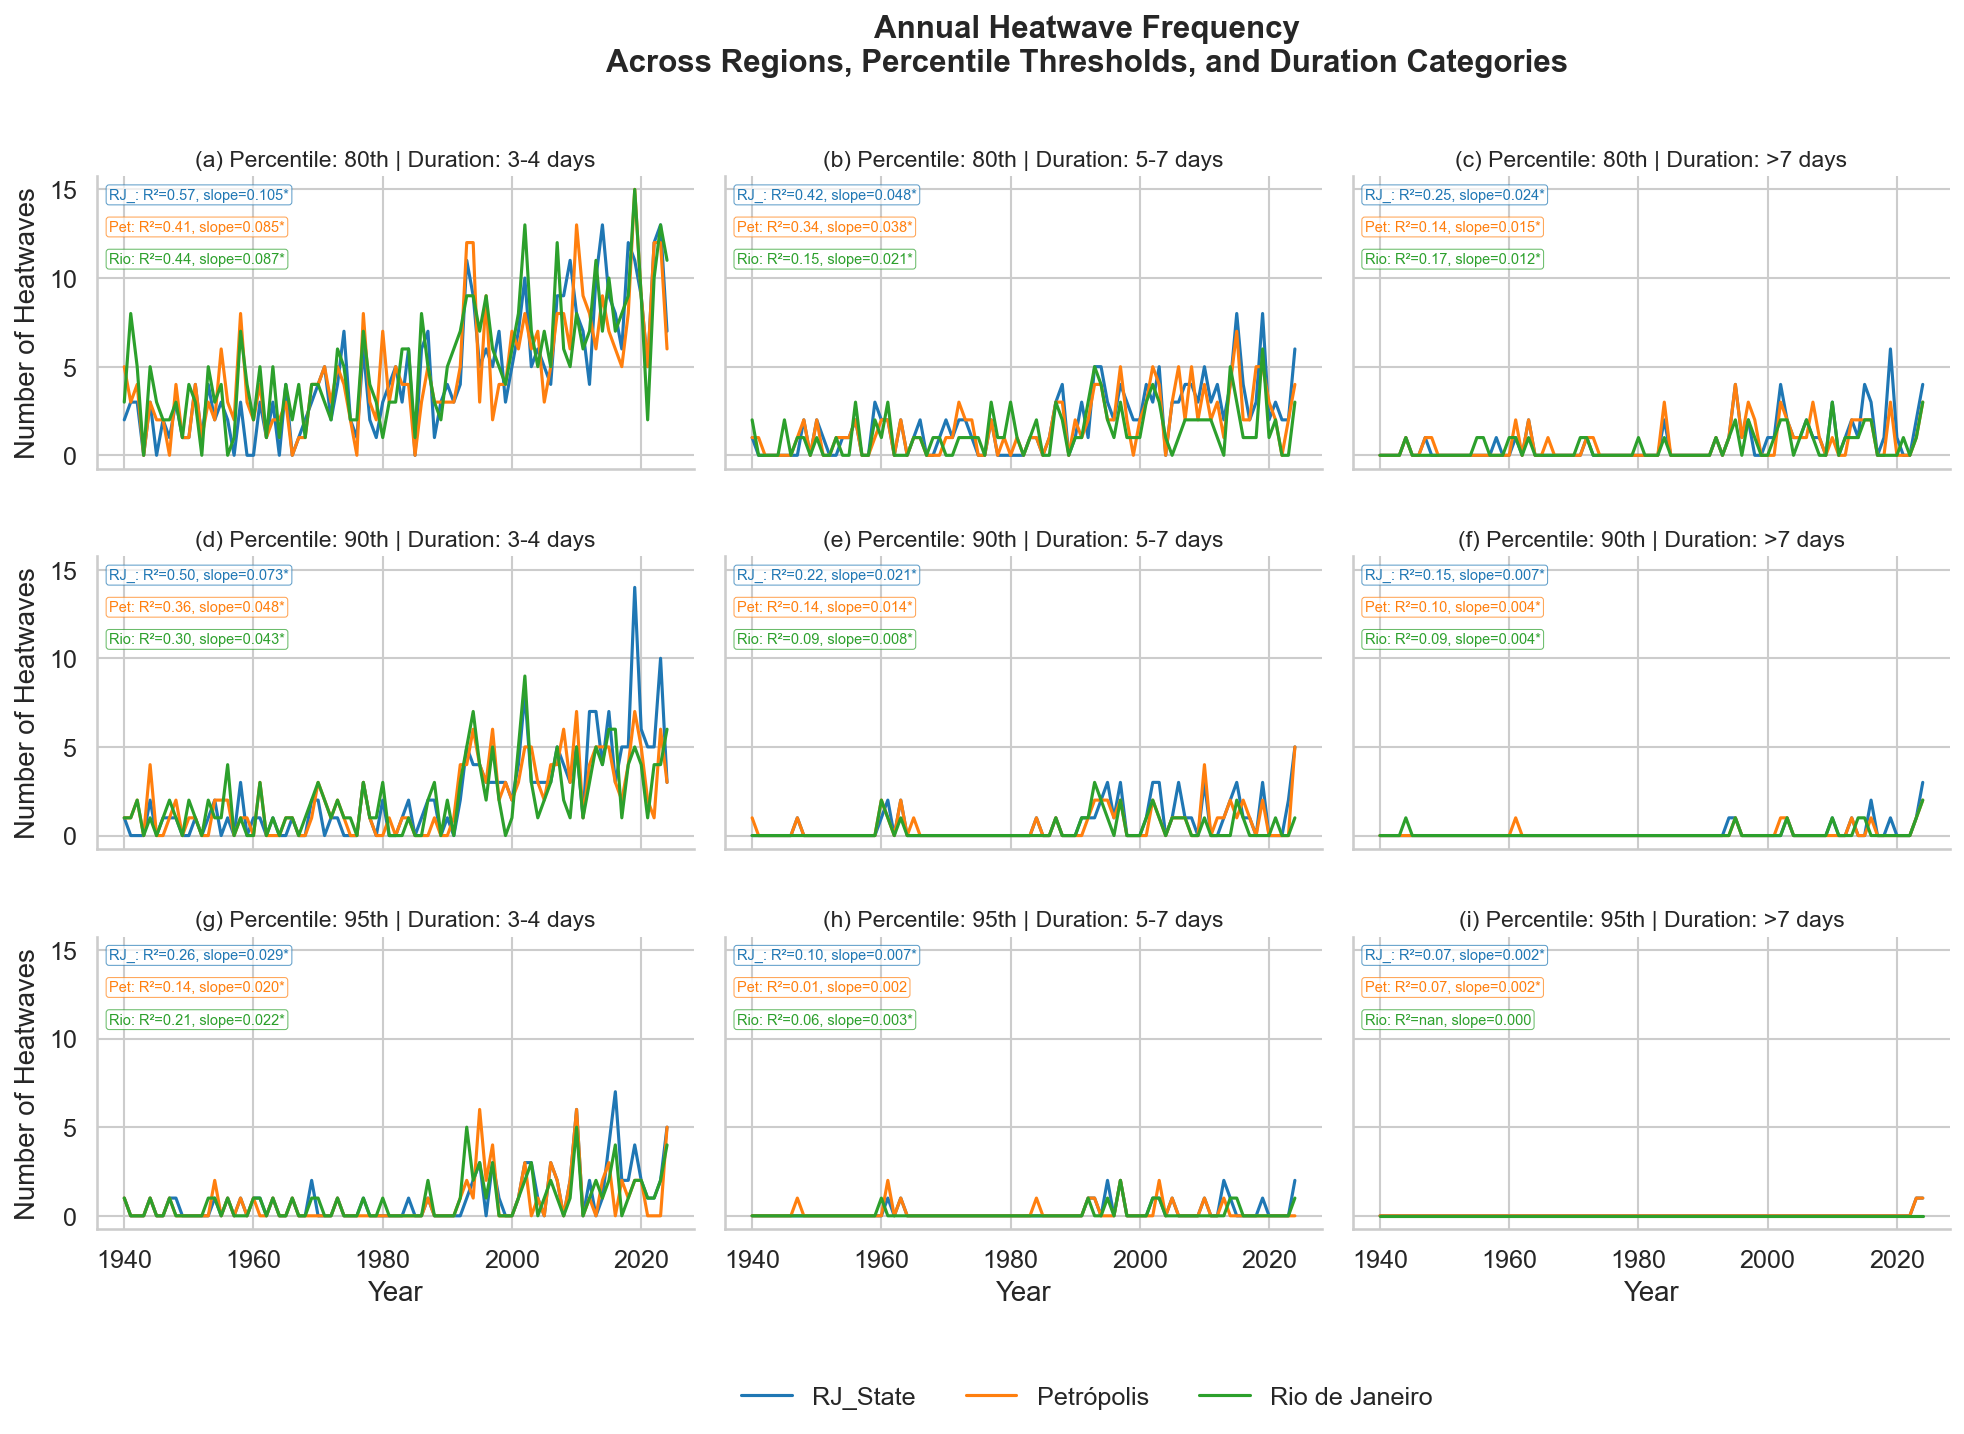

In [7]:
# ==============================================================================
# 3. Generate Time Series Panel (Final Adjustments)
# ==============================================================================

# 1. Legend Order and Color Palette Configuration
LEGEND_ORDER = ["RJ_State", "Petrópolis", "Rio de Janeiro"] 
PALETTE_COLORS = ["tab:blue", "tab:orange", "tab:green"]

g = sns.relplot(
    data=df_plot,
    x="year", 
    y="event_count",
    hue="region",            
    row="percentile",        
    col="duration_category", 
    kind="line",             
    
    hue_order=LEGEND_ORDER,   
    palette=PALETTE_COLORS,    
    
    height=3,                
    aspect=1.5,              
    row_order=PERCENTILE_ORDER,
    col_order=DURATION_ORDER,
    linewidth=1.5,

    facet_kws={'sharey': True, 'sharex': True}
)

# --- Main Loop: Statistics Calculation & Unified Titles ---
num_cols = len(DURATION_ORDER)

for row_idx, pct in enumerate(PERCENTILE_ORDER):
    for col_idx, dur in enumerate(DURATION_ORDER):
        ax = g.axes[row_idx, col_idx]
        
        # --- 1. Generate Subplot Label (a, b, c...) ---
        plot_index = row_idx * num_cols + col_idx
        label_letter = string.ascii_lowercase[plot_index]
        
        # --- 2. Create Unified Title ---
        # Combine the label letter and the descriptive title into a single string
        # to ensure proper alignment and spacing.
        full_title = f"({label_letter}) Percentile: {pct}th | Duration: {dur}"
        
        ax.set_title(full_title, loc='center', fontsize=11, fontweight='normal', pad=5)

        # --- 3. Compute and Display Linear Regression Statistics ---
        y_position = 0.96  # Initial y-position for the stats text (top)
        
        for region, color in zip(LEGEND_ORDER, PALETTE_COLORS):
            data_subset = df_plot[
                (df_plot['region'] == region) & 
                (df_plot['percentile'] == pct) & 
                (df_plot['duration_category'] == dur)
            ]
            
            if len(data_subset) > 2:  
                x = data_subset['year'].values
                y = data_subset['event_count'].values
                
                slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
                r_squared = r_value ** 2
                significance = '*' if p_value < 0.05 else ''
                
                text = f"{region[:3]}: R²={r_squared:.2f}, slope={slope:.3f}{significance}"
                
                ax.text(
                    0.02, y_position, text,
                    transform=ax.transAxes,
                    fontsize=7,
                    color=color,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor=color, linewidth=0.5)
                )
                
                y_position -= 0.11 # Vertical spacing between text boxes

# --- Final Layout Adjustments ---
g.set_axis_labels("Year", "Number of Heatwaves")

# Main Figure Title
g.fig.suptitle(
    "Annual Heatwave Frequency\nAcross Regions, Percentile Thresholds, and Duration Categories",
    x=0.5, y=1.02, fontsize=15, weight='bold'
)

# Reposition Legend
sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(0.5, -0.03), 
    ncol=3, title=None, frameon=False
)

# Adjust Subplot Spacing
g.fig.subplots_adjust(top=0.9, bottom=0.12, hspace=0.3)

# --- Save Figure ---
g.fig.savefig(
    r"C:\Users\rafaq\EASG690\Final_Project\scripts\heatwave_analysis\outputs\heatwave_timeseries_panel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Figure 1 - — Annual Heatwave Frequency Across Regions, Percentile Thresholds, and Duration Categories (1940–2024)

**Caption:** Temporal evolution of annual heatwave frequency (1940–2023) for Rio de Janeiro State (blue), Petrópolis municipality (orange), and Rio de Janeiro municipality (green). The panels are organized by intensity thresholds (rows) and duration categories (columns). Inset boxes display the coefficient of determination ($R^2$) and slope of the linear regression for each region, indicating long-term trends; abbreviations in these boxes denote Rio de Janeiro State (RJ_), Petrópolis municipality (Pet), and Rio de Janeiro municipality (Rio). Statistical significance ($p < 0.05$) is denoted by an asterisk. Panels (a), (b), and (c) represent durations of 3–4 days, 5–7 days, and >7 days, respectively, for the 80th percentile; (d), (e), and (f) represent the same duration sequence for the 90th percentile; and (g), (h), and (i) correspond to the 95th percentile.

**Analysis:**
Based on the figure, there is a clear and substantial increase in the occurrence of heatwaves across the three regions analyzed — the state of Rio de Janeiro, the municipality of Rio de Janeiro, and Petrópolis — particularly after the 1990s. This increase is most evident for events defined by the 80th percentile and lasting 3–4 days, which reach between 5 and 15 annual occurrences in recent decades, whereas in earlier periods only a few years exceeded five events.Regarding the linear regression analysis, the coefficient of determination ($R^2$) confirms a stronger statistical fit for these moderate-intensity (80th percentile) and short-duration (3–4 days) heatwaves, indicating a well-defined warming trend. Specifically, the slope values in this category suggest a rate of increase of approximately one additional heatwave event every decade (slope $\approx$ 0.10). While the trend is consistent across regions, the municipalities of Rio de Janeiro and Petrópolis exhibit slightly lower rates compared to the state aggregate.Another important finding is that Petrópolis, despite its location in a mountainous area with distinct physiographic characteristics (tropical highland climate), displays a frequency increase similar to that of Rio de Janeiro municipality. This suggests that the intensification of heatwave events is occurring broadly across the state, including in typically cooler environments such as Petrópolis, which is characterized by a tropical highland climate. In contrast, the slopes and $R^2$ values for higher intensity thresholds (95th percentile) and prolonged durations (>7 days) remain low, reflecting the rarity and lack of a clear linear trend for these extreme events in the historical record.


---
## 4. Analysis: Spatial Distribution Maps
## Spatial Heatwave Frequency Analysis (RJ Municipalities)

This section generates high-resolution spatial panels showing the **annual frequency of heatwave events** across all municipalities in the state of Rio de Janeiro (Brazil). We examine heatwaves using:

- **Three percentile thresholds:** 80th, 90th, 95th  
- **Three duration categories:** 3–4 days, 5–7 days, and >7 days  
- **Two multi-decadal periods:**  
  - *1980–2001* (baseline)  
  - *2002–2024* (recent period)

The purpose is to evaluate spatial patterns and temporal changes in heatwave activity, highlighting where events have become more common and how frequency varies by intensity (percentile) and persistence (duration).

The script below:

1. Loads municipality boundaries and heatwave event records.  
2. Calculates **annual heatwave frequency** for each municipality, duration class, and time period.  
3. Produces **2 × 3 publication-quality map panels** for each percentile threshold.  
4. Uses consistent color scales and geographic annotation for comparability across space and time.

The resulting figures allow us to visually assess how extreme heat events have evolved across Rio de Janeiro over the last four decades.


<>:140: SyntaxWarning: invalid escape sequence '\h'
<>:140: SyntaxWarning: invalid escape sequence '\h'
C:\Users\rafaq\AppData\Local\Temp\ipykernel_22652\978702008.py:140: SyntaxWarning: invalid escape sequence '\h'
  f"\heatwave_maps_percentile_{pct}.png",


📂 Loading geographic datasets...

🎨 Generating Panel for 80th Percentile...


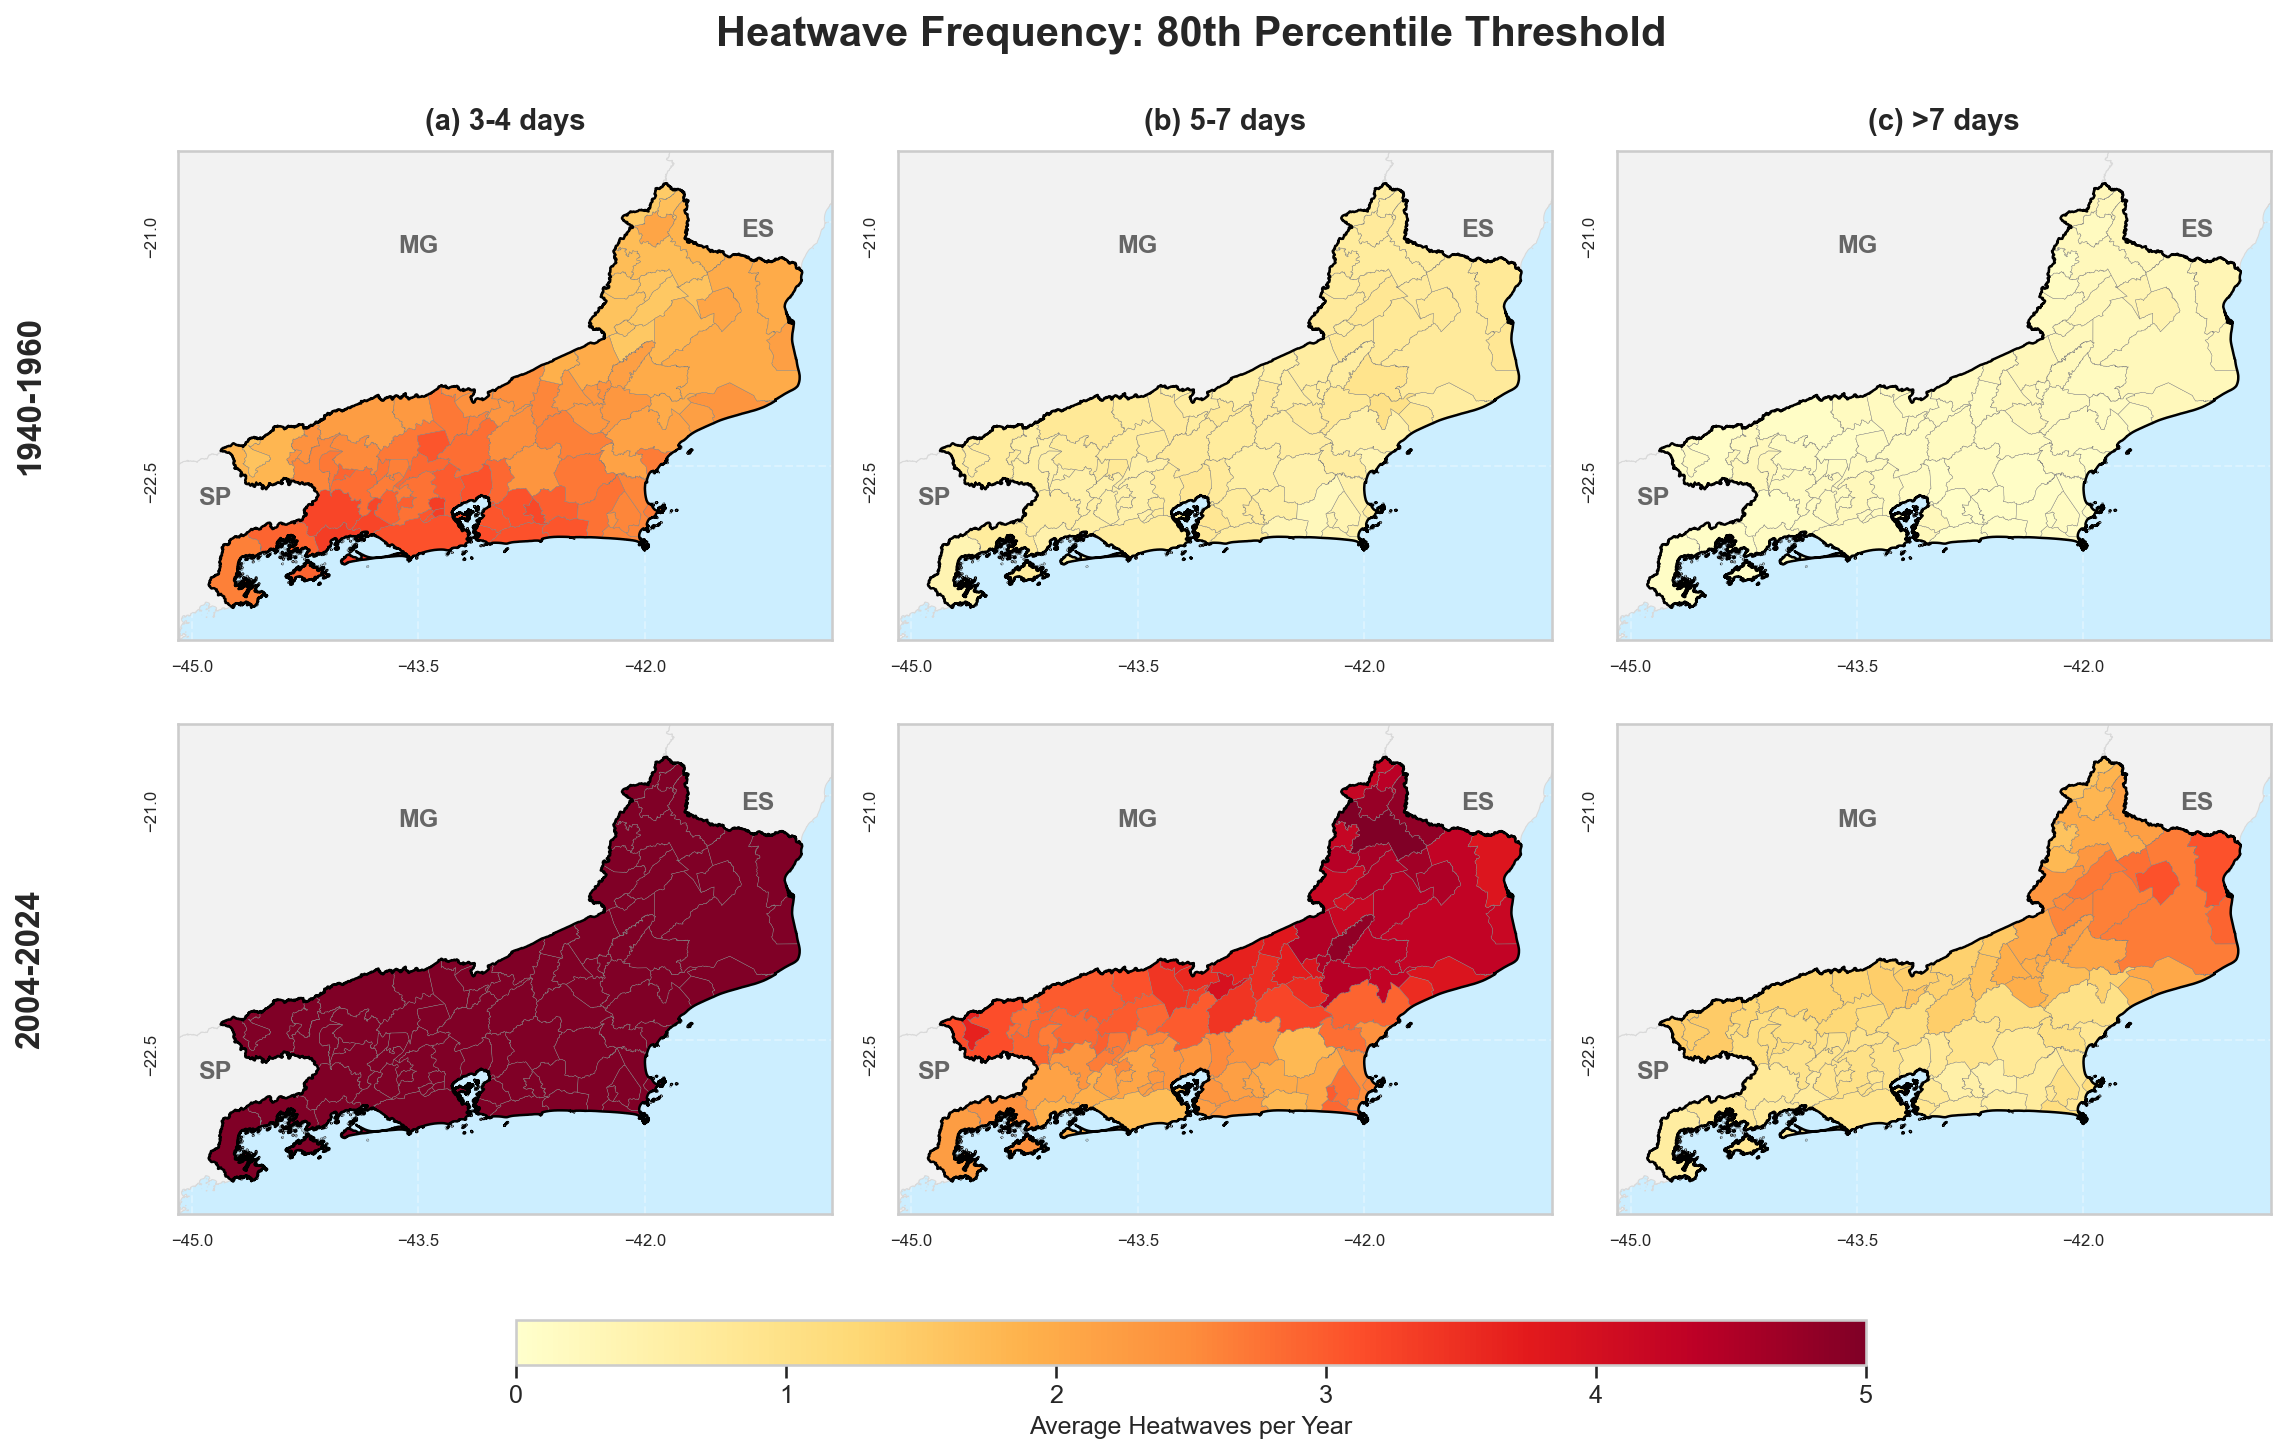


🎨 Generating Panel for 90th Percentile...


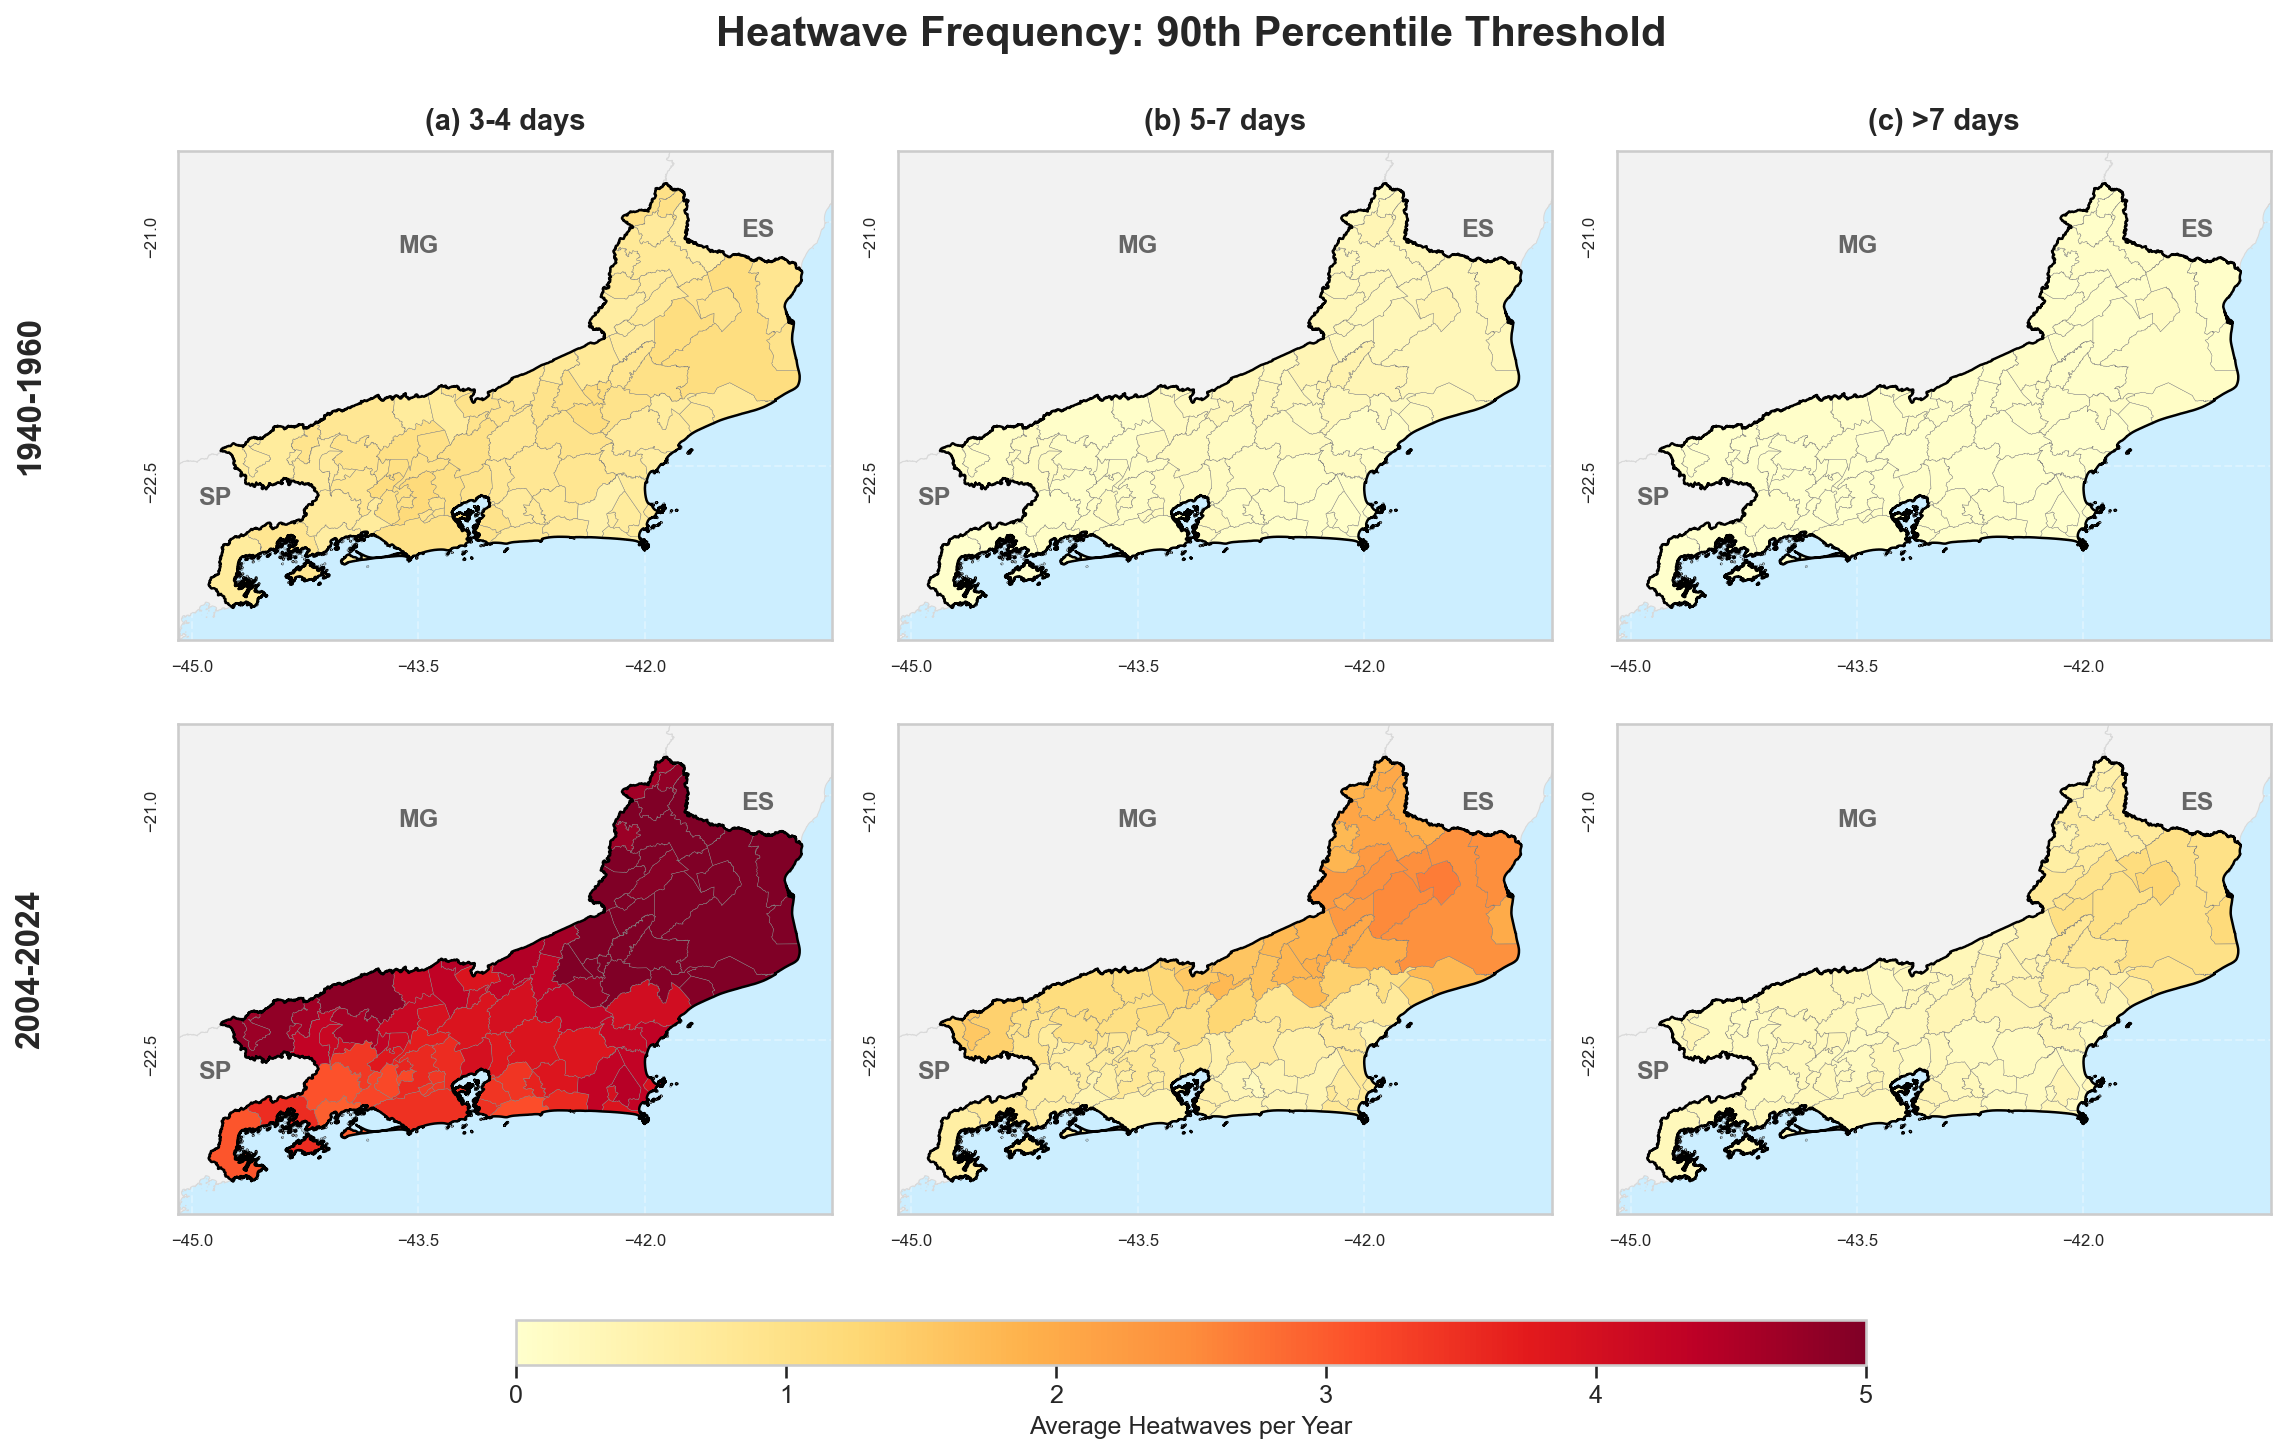


🎨 Generating Panel for 95th Percentile...


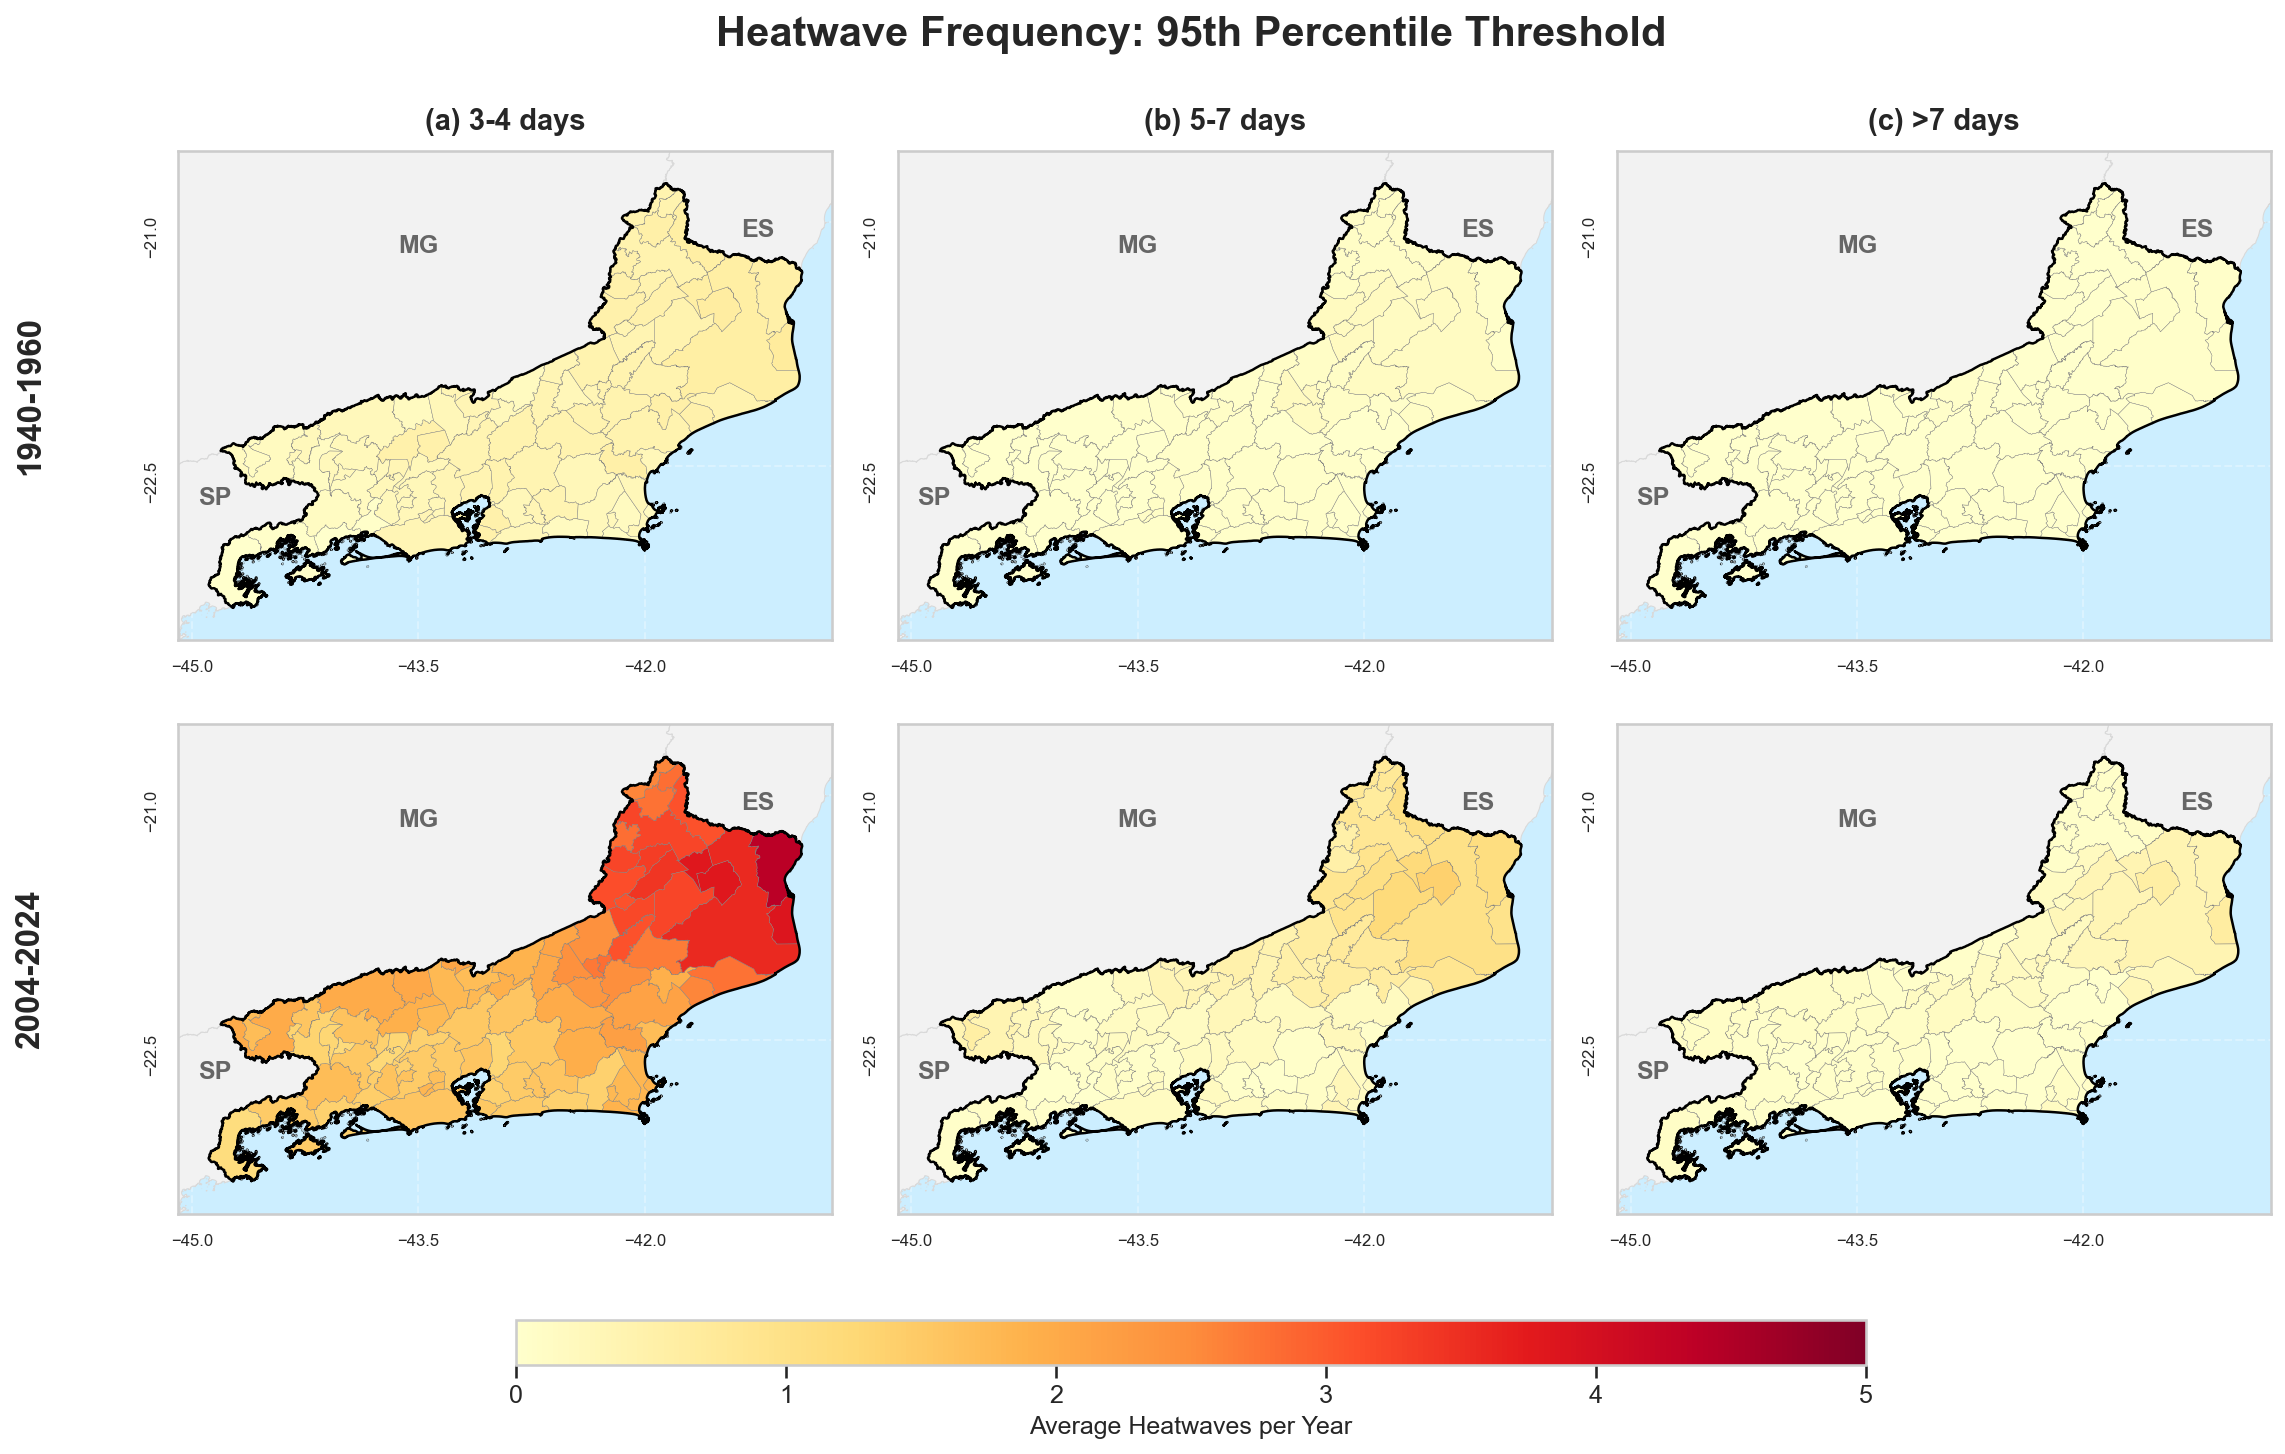

In [5]:
## Load spatial boundaries (Brazil states, RJ municipalities, RJ state outline) and the master heatwave events table ##
PATH_SHP_BR   = r"C:/Users/rafaq/OneDrive/Documentos/Tese_Brasil/municipios_RJ/BR_UF_2024/BR_UF_2024.shp"
PATH_SHP_MUNI = r"C:/Users/rafaq/OneDrive/Documentos/Tese_Brasil/municipios_RJ/RJ_Municipios_2024/RJ_Municipios_2024.shp"
PATH_SHP_UF   = r"C:/Users/rafaq/OneDrive/Documentos/Tese_Brasil/municipios_RJ/RJ_UF_2024/RJ_UF_2024.shp"
PATH_EVENTS   = r"C:\Users\rafaq\EASG690\Final_Project\scripts\heatwave_analysis\outputs\MASTER_events_all_regions.csv"

## Define analysis settings: time periods, percentile thresholds, duration classes, and visualization parameters ##
PERIODS_LIST = [
    ('1940-1960', (1940, 1960)),
    ('2004-2024', (2004, 2024))
]
PERCENTILES = [80, 90, 95]
DURATIONS = ['3-4 days', '5-7 days', '>7 days']
CMAP = "YlOrRd"
VMAX_GLOBAL = 5.0 

# Colors
COLOR_OCEAN = '#cceeff'
COLOR_LAND  = '#f2f2f2'
COLOR_BORDER_BR = '#d9d9d9'

TITLES_MAP = {
    '3-4 days': '(a) 3-4 days',
    '5-7 days': '(b) 5-7 days',
    '>7 days':  '(c) >7 days'
}

# Adjusted Coordinates 
NEIGHBORS_LABELS = [
    {'text': 'MG', 'x': -43.5, 'y': -21.15}, 
    {'text': 'SP', 'x': -44.85, 'y': -22.7}, 
    {'text': 'ES', 'x': -41.25, 'y': -21.05}  
]

# ==============================================================================
# 2. Load Data and Maps
# ==============================================================================
print("📂 Loading geographic datasets...")
df_events = pd.read_csv(PATH_EVENTS)
df_muni = df_events[df_events['region'] != 'RJ_State'].copy()

gdf_br = gpd.read_file(PATH_SHP_BR)
gdf_muni = gpd.read_file(PATH_SHP_MUNI)
gdf_state = gpd.read_file(PATH_SHP_UF)

col_name_shp = 'NM_MUN' if 'NM_MUN' in gdf_muni.columns else gdf_muni.columns[0]
df_muni['region_join'] = df_muni['region'].str.upper()
gdf_muni['region_join'] = gdf_muni[col_name_shp].str.upper()

# ==============================================================================
# 3. Compute Zoom Extent
# ==============================================================================
minx, miny, maxx, maxy = gdf_state.total_bounds
margin = 0.2 
xlim = (minx - margin, maxx + margin)
ylim = (miny - margin, maxy + margin)

# ==============================================================================
# 4. Helper Function
# ==============================================================================
def get_spatial_subset(df, percentile, start, end):
    mask = (df['year'] >= start) & (df['year'] <= end) & (df['percentile'] == percentile)
    df_filtered = df[mask].copy()
    counts = df_filtered.groupby(['region_join', 'duration_category']).size().reset_index(name='total_events')
    n_years = end - start + 1
    counts['annual_freq'] = counts['total_events'] / n_years
    return counts

# ==============================================================================
# 5. Map Generation
# ==============================================================================

for pct in PERCENTILES:
    print(f"\n🎨 Generating Panel for {pct}th Percentile...")
    
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    fig.suptitle(f"Heatwave Frequency: {pct}th Percentile Threshold", fontsize=20, weight='bold', y=0.96)
    
    for row_idx, (period_label, (start, end)) in enumerate(PERIODS_LIST):
        df_freq = get_spatial_subset(df_muni, pct, start, end)
        
        for col_idx, dur in enumerate(DURATIONS):
            ax = axes[row_idx, col_idx]
            
            # 1. Background
            ax.set_facecolor(COLOR_OCEAN)
            gdf_br.plot(ax=ax, facecolor=COLOR_LAND, edgecolor=COLOR_BORDER_BR, linewidth=0.5)
            
            # 2. Data
            subset = df_freq[df_freq['duration_category'] == dur]
            merged = gdf_muni.merge(subset, on='region_join', how='left')
            merged['annual_freq'] = merged['annual_freq'].fillna(0)
            
            merged.plot(column='annual_freq', ax=ax, cmap=CMAP, 
                        edgecolor='gray', linewidth=0.2,
                        vmin=0, vmax=VMAX_GLOBAL)
            
            # 3. RJ State Boundary
            gdf_state.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2)
            
            # 4. Neighbor Labels
            for label in NEIGHBORS_LABELS:
                ax.text(label['x'], label['y'], label['text'], 
                        fontsize=12, weight='bold', color='#666666', 
                        ha='center', va='center')

            # 5. Axis Configuration
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            
            ax.grid(True, linestyle='--', alpha=0.3, color='white')
            
            # Tick Control
            ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
            
            # [ADJUST HERE] Latitude Rotation
            ax.tick_params(axis='x', labelsize=8)               # Horizontal Longitude (default)
            ax.tick_params(axis='y', labelsize=8, rotation=90)  # Vertical Latitude
            
            # Titles
            if row_idx == 0:
                clean_title = TITLES_MAP.get(dur, dur)
                ax.set_title(clean_title, fontsize=14, weight='bold', pad=10)
            
            if col_idx == 0:
                ax.annotate(period_label, xy=(-0.25, 0.5), xycoords='axes fraction', 
                            fontsize=16, weight='bold', rotation=90, va='center')

    # Colorbar
    fig.subplots_adjust(bottom=0.15, top=0.88, hspace=0.1, wspace=0.1)
    cax = fig.add_axes([0.25, 0.06, 0.5, 0.03])
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=0, vmax=VMAX_GLOBAL))
    sm._A = []
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Average Heatwaves per Year', fontsize=12)
    
    fig.savefig(
        r"C:\Users\rafaq\EASG690\Final_Project\scripts\heatwave_analysis\outputs"
        f"\heatwave_maps_percentile_{pct}.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()


## Heatwave Frequency Across Rio de Janeiro State - Figures, 2, 3 and 4

**Caption:** Average annual heatwave frequency for two periods (1940–1960 and 2004–2024) across municipalities of Rio de Janeiro, separated by duration classes (3–4 days, 5–7 days, >7 days) and percentile thresholds (80th, 90th, 95th). Darker colors indicate higher heatwave occurrence.

**Analysis**
Based on Figures 2, 3, and 4, we observe that in the recent period (2004–2024) there was a marked increase in both the frequency and duration of heatwaves, especially at the 80th percentile threshold when compared with the historical baseline period (1940–1960). This indicates that the municipalities of the State of Rio de Janeiro, as a whole, have experienced a consistent rise in moderate heatwaves, which have become more common and more persistent in recent decades.

At the higher percentiles (90th and 95th), the most notable changes occur in short-duration heatwaves (3–4 days), suggesting that extreme events, although less frequent, have also intensified over time. Still within the 80th percentile, heatwaves lasting 5–7 days show a stronger concentration in the northern portion of the state, where the annual mean number of events exceeds that of the central–southern region. This spatial difference may be related to the flatter topography of northern Rio de Janeiro and the fact that this region is the last part of the state to receive the influence of frontal systems — such as cold fronts — which typically help reduce temperatures.

The northern region also stands out in the most intense heatwaves (95th percentile), particularly in shorter durations, indicating that it is the most susceptible portion of the state to heatwave occurrence.


## Spatial Change in Heatwave Frequency (Difference Maps)

In this section, we map the **change in heatwave frequency** across all municipalities in the state of Rio de Janeiro (Brazil), comparing two multi-decadal periods:

- **Past period:** 1940–1960 
- **Recent period:** 2004–2024  

For each municipality, we compute the **average number of heatwave events per year** in both periods and then calculate the difference:

> **Difference = Recent frequency (1940–1960) − Past frequency (2004–2024)**  

Positive values indicate an **increase** in heatwave frequency, while negative values indicate a **decrease**.

We consider:

- **Percentile thresholds:** 80th, 90th, and 95th  
- **Duration categories:**  
   3–4 days  
   5–7 days  
   above of 7 days  

The script below:

1. Loads the heatwave events dataset and municipal shapefiles.  
2. Computes the **annual frequency** of heatwaves for each municipality, percentile, duration category, and period.  
3. Calculates the **difference in frequency** between the recent and past periods.  
4. Produces a **3 × 3 panel** (rows = percentiles, columns = duration classes) using a **diverging color scale** (blue → decrease, white → no change, red → increase) with a symmetric range across all subplots.

These maps provide a spatially explicit view of where heatwaves have become more or less frequent, and how this change depends on the intensity (percentile) and persistence (duration) of the events.


📂 Loading data for difference calculation...
🔄 Computing global difference limits for symmetric color scale...
📊 Symmetric scale defined: -8 to +8 events/year

🎨 Generating Difference Maps Panel...


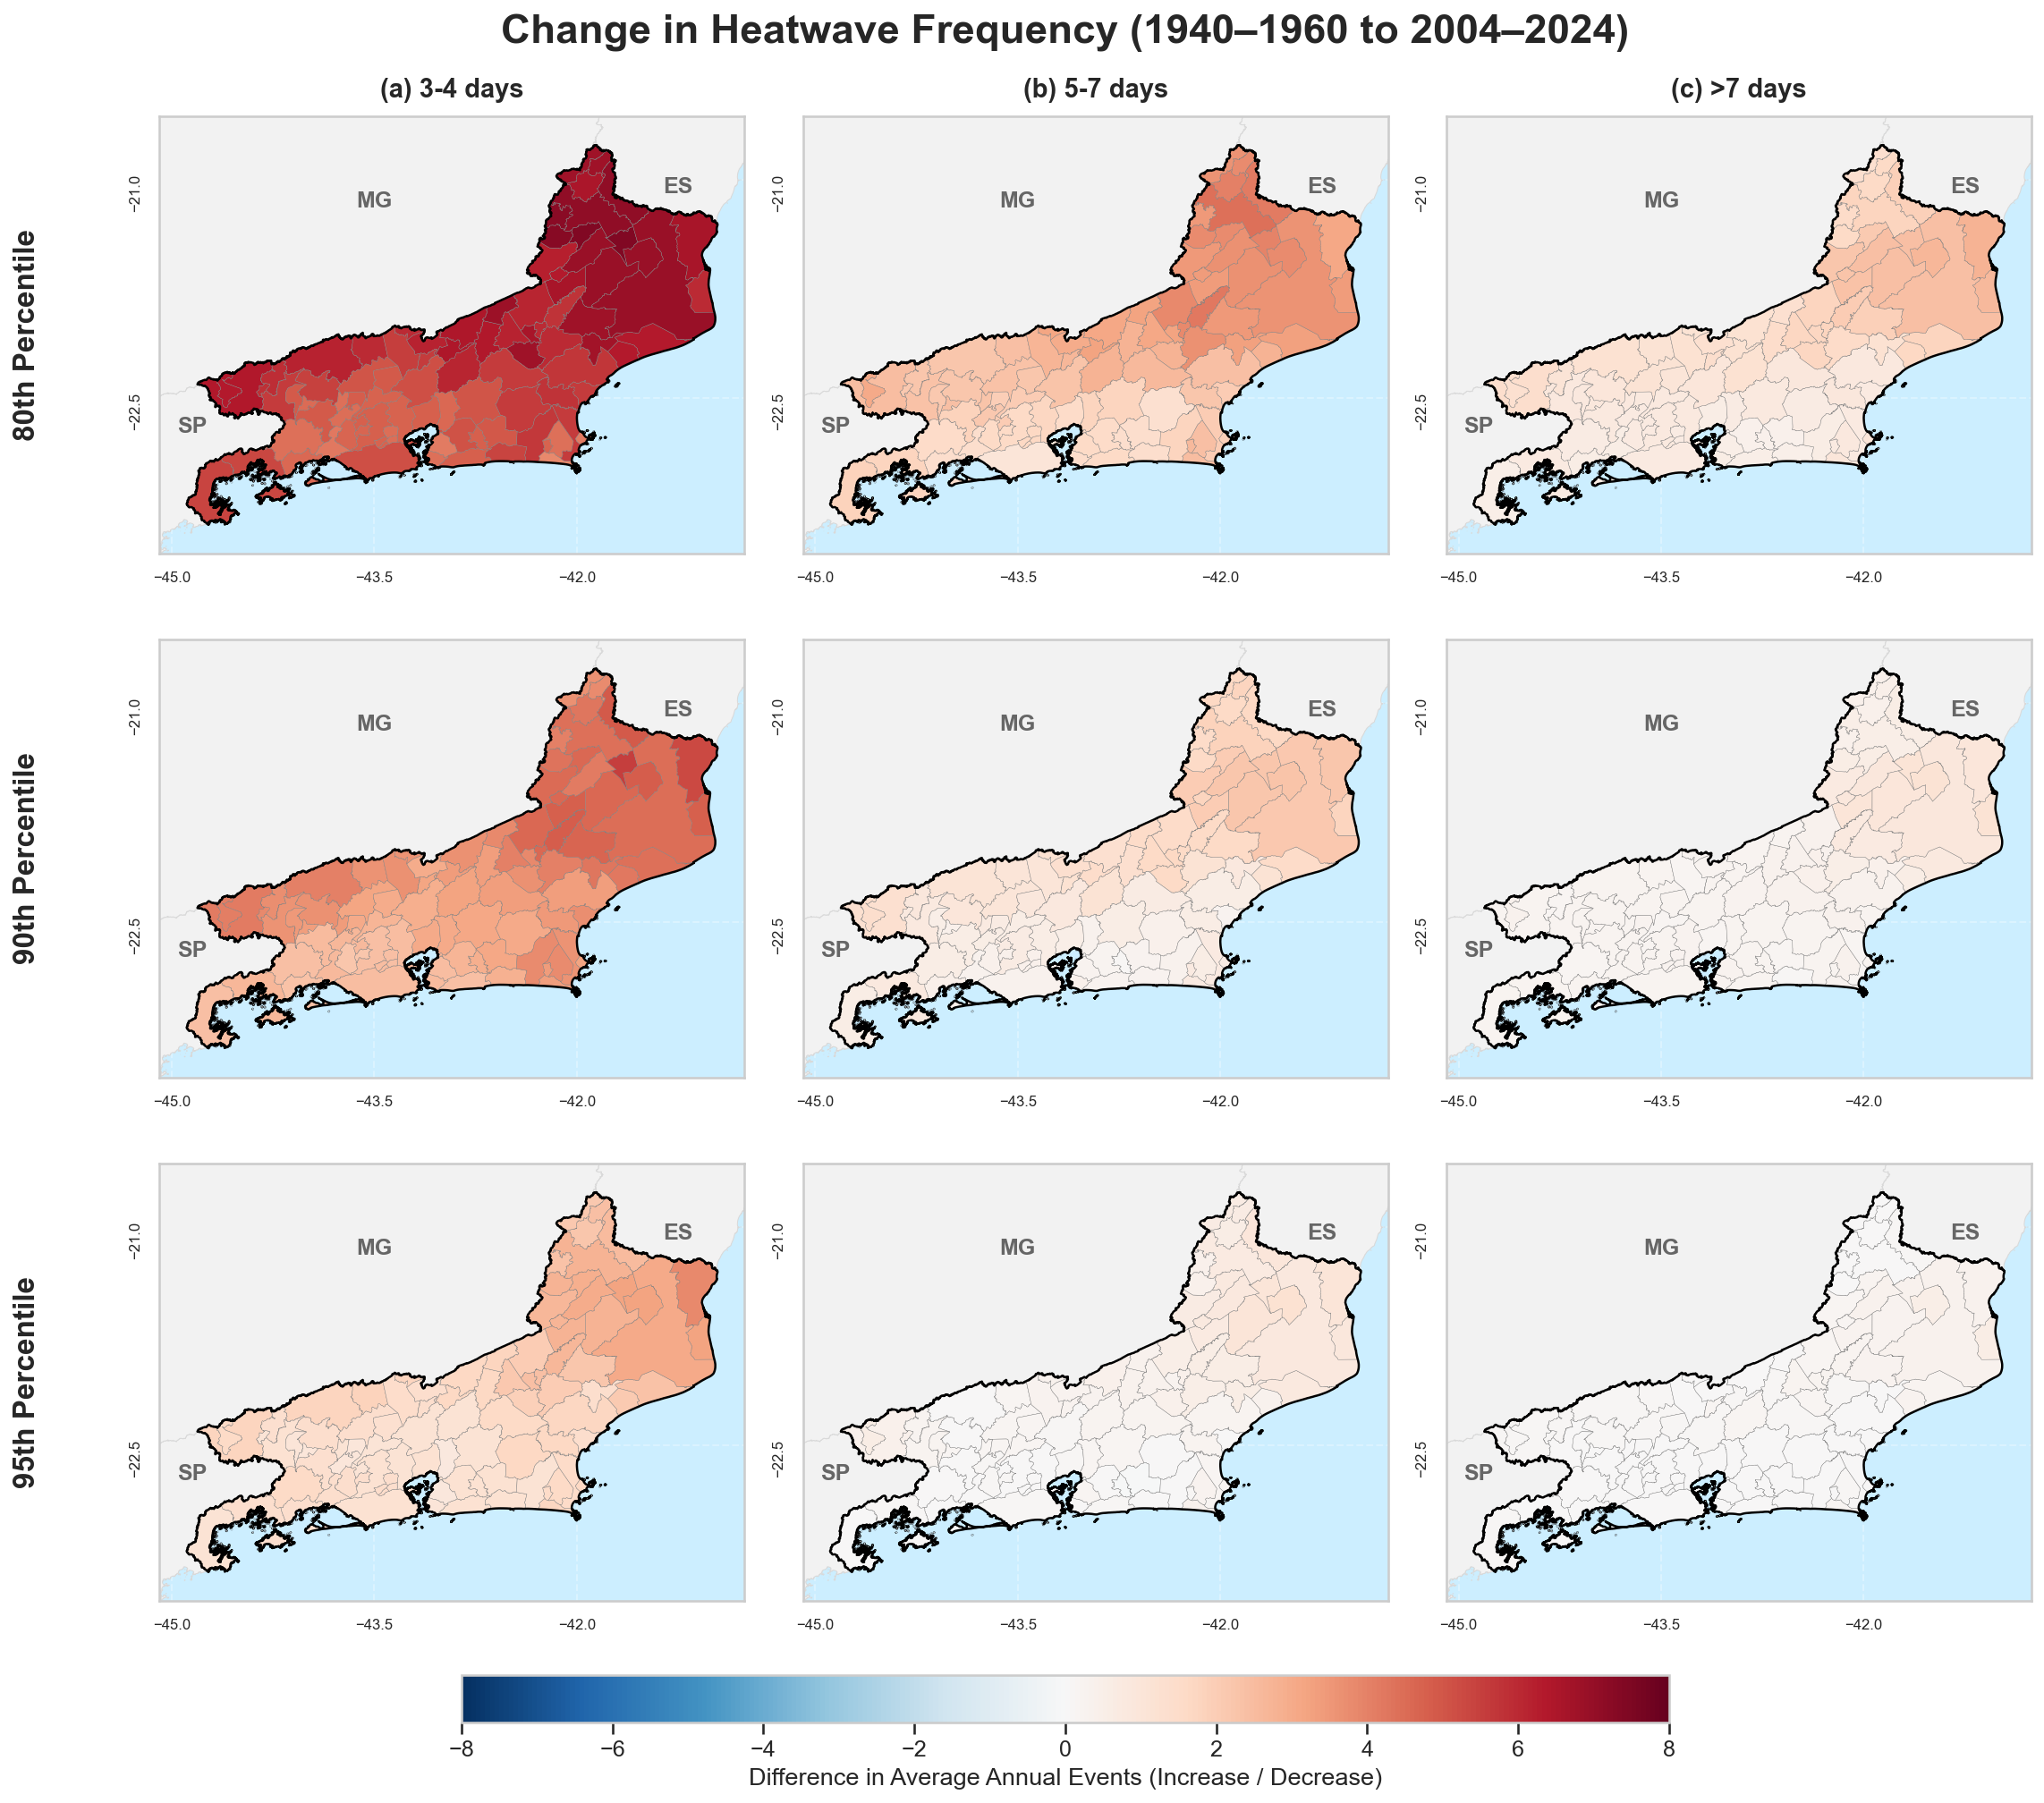

In [6]:
## Load spatial boundaries (Brazil states, RJ municipalities, RJ state outline) and the master heatwave events table ##
PATH_SHP_BR   = r"C:/Users/rafaq/OneDrive/Documentos/Tese_Brasil/municipios_RJ/BR_UF_2024/BR_UF_2024.shp"
PATH_SHP_MUNI = r"C:/Users/rafaq/OneDrive/Documentos/Tese_Brasil/municipios_RJ/RJ_Municipios_2024/RJ_Municipios_2024.shp"
PATH_SHP_UF   = r"C:/Users/rafaq/OneDrive/Documentos/Tese_Brasil/municipios_RJ/RJ_UF_2024/RJ_UF_2024.shp"
PATH_EVENTS   = r"C:\Users\rafaq\EASG690\Final_Project\scripts\heatwave_analysis\outputs\MASTER_events_all_regions.csv"

## Define analysis settings: time periods, percentile thresholds, duration classes, and visualization parameters ##
PERCENTILES = [80, 90, 95]
DURATIONS = ['3-4 days', '5-7 days', '>7 days']

# Visual Layout
CMAP_DIFF = "RdBu_r"  # Red (Increase) <-> White (No change) <-> Blue (Decrease)
COLOR_OCEAN = '#cceeff'
COLOR_LAND  = '#f2f2f2'
COLOR_BORDER_BR = '#d9d9d9'

TITLES_MAP = {
    '3-4 days': '(a) 3-4 days',
    '5-7 days': '(b) 5-7 days',
    '>7 days':  '(c) >7 days'
}

NEIGHBORS_LABELS = [
    {'text': 'MG', 'x': -43.5, 'y': -21.15},
    {'text': 'SP', 'x': -44.85, 'y': -22.7},
    {'text': 'ES', 'x': -41.25, 'y': -21.05}
]

# ==============================================================================
# 2. Load Data
# ==============================================================================
print("📂 Loading data for difference calculation...")
df_events = pd.read_csv(PATH_EVENTS)
df_muni = df_events[df_events['region'] != 'RJ_State'].copy()

gdf_br = gpd.read_file(PATH_SHP_BR)
gdf_muni = gpd.read_file(PATH_SHP_MUNI)
gdf_state = gpd.read_file(PATH_SHP_UF)

col_name_shp = 'NM_MUN' if 'NM_MUN' in gdf_muni.columns else gdf_muni.columns[0]
df_muni['region_join'] = df_muni['region'].str.upper()
gdf_muni['region_join'] = gdf_muni[col_name_shp].str.upper()

# Zoom over RJ
minx, miny, maxx, maxy = gdf_state.total_bounds
margin = 0.2
xlim = (minx - margin, maxx + margin)
ylim = (miny - margin, maxy + margin)

# ==============================================================================
# 3. Difference Calculation Function
# ==============================================================================
def get_diff_data(df, percentile, duration, shapefile):
    """
    Compute the difference in annual heatwave frequency
    between 1940–1960 and 2004–2024 for a given percentile
    and duration category, merged onto the municipal shapefile.
    """

    # 1. Past frequency (1940–1960)
    mask_past = (
        (df['year'] >= 1940) & (df['year'] <= 1960) &
        (df['percentile'] == percentile) &
        (df['duration_category'] == duration)
    )
    count_past = (
        df[mask_past]
        .groupby('region_join')
        .size()
        .reset_index(name='count')
    )
    n_years_past = 1960 - 1940 + 1
    count_past['freq'] = count_past['count'] / n_years_past

    # 2. Recent frequency (2004–2024)
    mask_recent = (
        (df['year'] >= 2004) & (df['year'] <= 2024) &
        (df['percentile'] == percentile) &
        (df['duration_category'] == duration)
    )
    count_recent = (
        df[mask_recent]
        .groupby('region_join')
        .size()
        .reset_index(name='count')
    )
    n_years_recent = 2024 - 2004 + 1
    count_recent['freq'] = count_recent['count'] / n_years_recent

    # 3. Merge onto shapefile and compute difference
    # Merge with shapefile to ensure all municipalities are included
    merged = (
        shapefile
        .merge(count_past[['region_join', 'freq']], on='region_join', how='left')
        .rename(columns={'freq': 'freq_past'})
    )
    merged = (
        merged
        .merge(count_recent[['region_join', 'freq']], on='region_join', how='left')
        .rename(columns={'freq': 'freq_recent'})
    )

    # Fill NaNs with 0 where no events occurred
    merged['freq_past'] = merged['freq_past'].fillna(0)
    merged['freq_recent'] = merged['freq_recent'].fillna(0)

    # Compute the difference (Recent − Past)
    merged['diff'] = merged['freq_recent'] - merged['freq_past']

    return merged

# ==============================================================================
# 4. Automatic Scale Calculation (Symmetric Color Scale)
# ==============================================================================
print("🔄 Computing global difference limits for symmetric color scale...")
max_abs_diff = 0
for pct in PERCENTILES:
    for dur in DURATIONS:
        temp_data = get_diff_data(df_muni, pct, dur, gdf_muni)
        local_max = temp_data['diff'].abs().max()
        if local_max > max_abs_diff:
            max_abs_diff = local_max

# Round up (e.g., 3.2 → 4.0) for a cleaner colorbar
import math
VMAX_DIFF = math.ceil(max_abs_diff)
print(f"📊 Symmetric scale defined: -{VMAX_DIFF} to +{VMAX_DIFF} events/year")

# ==============================================================================
# 5. Generate 3×3 Panel
# ==============================================================================
print("\n🎨 Generating Difference Maps Panel...")

# Big Figure: 3 rows (Percentiles) × 3 columns (Durations)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
fig.suptitle(
    "Change in Heatwave Frequency (1940–1960 to 2004–2024)",
    fontsize=22,
    weight='bold',
    y=0.95
)

for row_idx, pct in enumerate(PERCENTILES):
    for col_idx, dur in enumerate(DURATIONS):
        ax = axes[row_idx, col_idx]

        # 1. Data for this panel
        gdf_plot = get_diff_data(df_muni, pct, dur, gdf_muni)

        # 2. Background layers
        ax.set_facecolor(COLOR_OCEAN)
        gdf_br.plot(
            ax=ax,
            facecolor=COLOR_LAND,
            edgecolor=COLOR_BORDER_BR,
            linewidth=0.5
        )

        # 3. Difference Map (Diverging)
        gdf_plot.plot(
            column='diff',
            ax=ax,
            cmap=CMAP_DIFF,
            edgecolor='gray',
            linewidth=0.2,
            vmin=-VMAX_DIFF,
            vmax=VMAX_DIFF  # Symmetric scale
        )

        # 4. RJ boundary and neighboring state labels
        gdf_state.plot(
            ax=ax,
            facecolor='none',
            edgecolor='black',
            linewidth=1.2
        )
        for label in NEIGHBORS_LABELS:
            ax.text(
                label['x'],
                label['y'],
                label['text'],
                fontsize=12,
                weight='bold',
                color='#666666',
                ha='center',
                va='center'
            )

        # 5. Axes and zoom
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(True, linestyle='--', alpha=0.3, color='white')
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8, rotation=90)  

        # 6. Titles
        # Column titles (Duration) – only on the first row
        if row_idx == 0:
            ax.set_title(
                TITLES_MAP.get(dur, dur),
                fontsize=14,
                weight='bold',
                pad=10
            )

        # Row labels (Percentile) – only on the first column
        if col_idx == 0:
            ax.annotate(
                f"{pct}th Percentile",
                xy=(-0.25, 0.5),
                xycoords='axes fraction',
                fontsize=16,
                weight='bold',
                rotation=90,
                va='center'
            )

# Shared Colorbar
fig.subplots_adjust(bottom=0.10, top=0.90, hspace=0.15, wspace=0.1)
cax = fig.add_axes([0.25, 0.04, 0.5, 0.025])
sm = plt.cm.ScalarMappable(
    cmap=CMAP_DIFF,
    norm=plt.Normalize(vmin=-VMAX_DIFF, vmax=VMAX_DIFF)
)
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(
    'Difference in Average Annual Events (Increase / Decrease)',
    fontsize=13
)

fig.savefig(
        r"C:\Users\rafaq\EASG690\Final_Project\scripts\heatwave_analysis\outputs\heatwave_maps_diff_allpercentile.png",
        dpi=300,
        bbox_inches='tight'
    )
plt.show()


## Difference in Average Annual Heatwave Events across Rio de Janeiro State

**Figure 5.** Spatial difference in average annual heatwave frequency between the historical period (1940–1960) and the recent period (2004–2024), across municipalities of Rio de Janeiro. Panels display results by percentile threshold (rows: 80th, 90th, 95th) and duration category (columns: 3–4 days, 5–7 days, >7 days). Positive values indicate an increase in heatwave frequency in the modern climate. A diverging color scale highlights the magnitude and spatial distribution of these changes.

**Analysis**
Based on Figure 5, we observe that the largest differences in the average annual number of heatwave events occur at the 80th percentile, particularly for short-duration heatwaves (3–4 days), with the greatest increases concentrated in the northern portion of the state of Rio de Janeiro. This pattern reinforces that moderate heatwaves are the category that has intensified the most over recent decades.

At the higher percentiles (90th and 95th), the most pronounced differences also appear in the 3–4-day heatwaves, while the differences decrease as event duration increases, tending toward values close to zero. Even so, the northern region of the state remains the area with the highest relative increases, showing more than four additional events per year, whereas the central–southern region exhibits more moderate changes, generally between two and three additional events per year.

These results confirm the pattern shown in Figures 2, 3, and 4, indicating that northern Rio de Janeiro is consistently the region most susceptible to the intensification of heatwaves in terms of both frequency and persistence. Furthermore, no negative differences were observed, which is consistent with the statewide time series presented in Figure 1: the state of Rio de Janeiro exhibits a clear and continuous upward trend in heatwave frequency over recent decades, particularly for moderate-intensity events (80th percentile).
